In [1]:
import numpy as np
import matplotlib.pyplot as plt

# HELPER IMPORTS AND FUNCTIONS: Common imports, optimization helpers, and synthetic
# dataset builders used across the Chapter 6 exercise cells below.
# ---------------------------------------------------------------------

def ensure_2d_features(X):
    # Most of the later helpers assume features are arranged as a matrix
    # of shape (P, N).  If X is a 1D array, treat it as a single-feature
    # dataset and promote it to shape (P, 1).
    X = np.asarray(X)
    return X[:, None] if X.ndim == 1 else X

def linear_model(X, w):
    # Generic linear score a(x) = w0 + w_1:N^T x that works for both the
    # 1D and multi-dimensional exercises in this notebook.
    X2 = ensure_2d_features(X)
    return w[0] + X2 @ w[1:]

def sigmoid(z):
    # Stable logistic sigmoid used throughout the notebook.
    z = np.clip(z, -100, 100)
    return 1.0 / (1.0 + np.exp(-z))

def gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=50, misclass_fn=None):
    # Standard fixed-step gradient descent.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    if misclass_fn is not None:
        misclass_history = [misclass_fn(w, X, y)]

    for _ in range(max_its):
        w = w - alpha * grad_fn(w, X, y)
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

        if misclass_fn is not None:
            misclass_history.append(misclass_fn(w, X, y))

    if misclass_fn is None:
        return np.array(weight_history), np.array(cost_history)

    return np.array(weight_history), np.array(cost_history), np.array(misclass_history)

def normalized_gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=100):
    # Variant that normalizes the gradient direction before each step.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(max_its):
        g = grad_fn(w, X, y)
        gnorm = np.linalg.norm(g)
        if gnorm < 1e-12:
            break
        w = w - alpha * g / gnorm
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)

def misclassifications_binary01(w, X, y):
    # Hard 0/1 predictions from sigmoid probabilities.
    preds = (sigmoid(linear_model(X, w)) >= 0.5).astype(int)
    return int(np.sum(preds != y))

def misclassifications_signed(w, X, y):
    # Hard {-1, +1} predictions from the sign of the linear score.
    preds = np.where(linear_model(X, w) >= 0, 1, -1)
    return int(np.sum(preds != y))

def softmax_cost_signed(w, X, y):
    # Two-class softmax/logistic loss for labels in {-1, +1}.
    margins = y * linear_model(X, w)
    return np.mean(np.logaddexp(0.0, -margins))

def grad_softmax_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = -y * sigmoid(-margins)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def perceptron_cost_signed(w, X, y):
    margins = y * linear_model(X, w)
    return np.mean(np.maximum(0.0, -margins))

def subgradient_perceptron_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = np.where(margins <= 0, -y, 0.0)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def first_perfect_step(misclass_history):
    perfect_steps = np.where(misclass_history == 0)[0]
    return None if perfect_steps.size == 0 else int(perfect_steps[0])

def make_noisy_2d_dataset(seed=8, flips=5):
    # Figure 6.10-style noisy 2D dataset used by Exercises 6.8,
    # 6.9, and 6.12.
    rng = np.random.RandomState(seed)
    class_neg = rng.multivariate_normal(
        mean=[-1.7, -1.2],
        cov=[[0.45, 0.10], [0.10, 0.45]],
        size=50,
    )
    class_pos = rng.multivariate_normal(
        mean=[1.7, 1.2],
        cov=[[0.45, -0.05], [-0.05, 0.45]],
        size=50,
    )
    X = np.vstack([class_neg, class_pos])
    y = np.concatenate([-np.ones(50), np.ones(50)])
    flip_indices = np.array([6, 18, 31, 64, 87][:flips]) if flips <= 5 else rng.choice(X.shape[0], size=flips, replace=False)
    y[flip_indices] *= -1
    return X, y, np.array(flip_indices)

def make_synthetic_breast_cancer_data(seed=11, noise=0.05, flips=10):
    # Synthetic 699-by-9 breast-cancer-style dataset for Exercise 6.13.
    rng = np.random.RandomState(seed)
    P = 699
    N = 9
    X = rng.randn(P, N)
    X[:, 1] = 0.6 * X[:, 0] + 0.8 * rng.randn(P)
    X[:, 3] = 0.5 * X[:, 2] + 0.8 * rng.randn(P)
    X[:, 5] = 0.4 * X[:, 4] + 0.8 * rng.randn(P)
    true_w = 2.5 * np.array([1.8, -1.5, 1.2, -1.0, 0.8, -0.7, 0.5, -0.4, 0.3])
    scores = X @ true_w + noise * rng.randn(P)
    y = np.where(scores >= 0, 1.0, -1.0)
    flip_indices = rng.choice(P, size=flips, replace=False)
    y[flip_indices] *= -1
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return X, y, flip_indices


Final weights: [-26.9573014   23.10454427]
Final cost: 2.507605970706478e-06
Misclassifications: 0


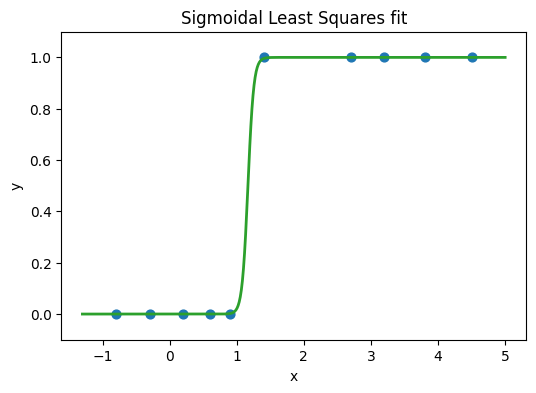

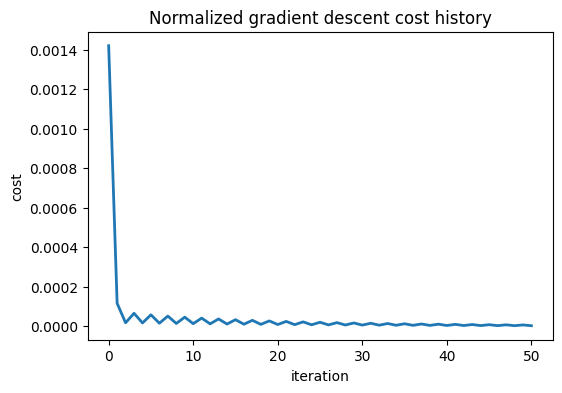

In [2]:
# QUESTION HANDLED: Earlier 1D least-squares logistic regression exercise.
# ---------------------------------------------------------------------
# Fit a sigmoid to 1D binary data using a least-squares objective and
# normalized gradient descent.
# ---------------------------------------------------------------------
# Textbook equations used here: the logistic-sigmoid model from Section 6.2 and
# the Least Squares objective in Equation (6.9).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# HELPER IMPORTS AND FUNCTIONS: Common imports, optimization helpers, and synthetic
# dataset builders used across the Chapter 6 exercise cells below.
# ---------------------------------------------------------------------

def ensure_2d_features(X):
    # Most of the later helpers assume features are arranged as a matrix
    # of shape (P, N).  If X is a 1D array, treat it as a single-feature
    # dataset and promote it to shape (P, 1).
    X = np.asarray(X)
    return X[:, None] if X.ndim == 1 else X

def linear_model(X, w):
    # Generic linear score a(x) = w0 + w_1:N^T x that works for both the
    # 1D and multi-dimensional exercises in this notebook.
    X2 = ensure_2d_features(X)
    return w[0] + X2 @ w[1:]

def sigmoid(z):
    # Stable logistic sigmoid used throughout the notebook.
    z = np.clip(z, -100, 100)
    return 1.0 / (1.0 + np.exp(-z))

def gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=50, misclass_fn=None):
    # Standard fixed-step gradient descent.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    if misclass_fn is not None:
        misclass_history = [misclass_fn(w, X, y)]

    for _ in range(max_its):
        w = w - alpha * grad_fn(w, X, y)
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

        if misclass_fn is not None:
            misclass_history.append(misclass_fn(w, X, y))

    if misclass_fn is None:
        return np.array(weight_history), np.array(cost_history)

    return np.array(weight_history), np.array(cost_history), np.array(misclass_history)

def normalized_gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=100):
    # Variant that normalizes the gradient direction before each step.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(max_its):
        g = grad_fn(w, X, y)
        gnorm = np.linalg.norm(g)
        if gnorm < 1e-12:
            break
        w = w - alpha * g / gnorm
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)

def misclassifications_binary01(w, X, y):
    # Hard 0/1 predictions from sigmoid probabilities.
    preds = (sigmoid(linear_model(X, w)) >= 0.5).astype(int)
    return int(np.sum(preds != y))

def misclassifications_signed(w, X, y):
    # Hard {-1, +1} predictions from the sign of the linear score.
    preds = np.where(linear_model(X, w) >= 0, 1, -1)
    return int(np.sum(preds != y))

def softmax_cost_signed(w, X, y):
    # Two-class softmax/logistic loss for labels in {-1, +1}.
    margins = y * linear_model(X, w)
    return np.mean(np.logaddexp(0.0, -margins))

def grad_softmax_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = -y * sigmoid(-margins)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def perceptron_cost_signed(w, X, y):
    margins = y * linear_model(X, w)
    return np.mean(np.maximum(0.0, -margins))

def subgradient_perceptron_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = np.where(margins <= 0, -y, 0.0)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def first_perfect_step(misclass_history):
    perfect_steps = np.where(misclass_history == 0)[0]
    return None if perfect_steps.size == 0 else int(perfect_steps[0])

def make_noisy_2d_dataset(seed=8, flips=5):
    # Figure 6.10-style noisy 2D dataset used by Exercises 6.8,
    # 6.9, and 6.12.
    rng = np.random.RandomState(seed)
    class_neg = rng.multivariate_normal(
        mean=[-1.7, -1.2],
        cov=[[0.45, 0.10], [0.10, 0.45]],
        size=50,
    )
    class_pos = rng.multivariate_normal(
        mean=[1.7, 1.2],
        cov=[[0.45, -0.05], [-0.05, 0.45]],
        size=50,
    )
    X = np.vstack([class_neg, class_pos])
    y = np.concatenate([-np.ones(50), np.ones(50)])
    flip_indices = np.array([6, 18, 31, 64, 87][:flips]) if flips <= 5 else rng.choice(X.shape[0], size=flips, replace=False)
    y[flip_indices] *= -1
    return X, y, np.array(flip_indices)

def make_synthetic_breast_cancer_data(seed=11, noise=0.05, flips=10):
    # Synthetic 699-by-9 breast-cancer-style dataset for Exercise 6.13.
    rng = np.random.RandomState(seed)
    P = 699
    N = 9
    X = rng.randn(P, N)
    X[:, 1] = 0.6 * X[:, 0] + 0.8 * rng.randn(P)
    X[:, 3] = 0.5 * X[:, 2] + 0.8 * rng.randn(P)
    X[:, 5] = 0.4 * X[:, 4] + 0.8 * rng.randn(P)
    true_w = 2.5 * np.array([1.8, -1.5, 1.2, -1.0, 0.8, -0.7, 0.5, -0.4, 0.3])
    scores = X @ true_w + noise * rng.randn(P)
    y = np.where(scores >= 0, 1.0, -1.0)
    flip_indices = rng.choice(P, size=flips, replace=False)
    y[flip_indices] *= -1
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return X, y, flip_indices

def least_squares_sigmoid_cost(w, x, y):
    s = sigmoid(linear_model(x, w))
    return np.mean((s - y) ** 2)

def grad_least_squares_sigmoid(w, x, y):
    a = linear_model(x, w)
    s = sigmoid(a)
    coeff = 2.0 * (s - y) * s * (1.0 - s) / x.size
    grad_w0 = np.sum(coeff)
    grad_w1 = np.sum(coeff * x)
    return np.array([grad_w0, grad_w1])

x_ls = np.array([-0.8, -0.3, 0.2, 0.6, 0.9, 1.4, 2.7, 3.2, 3.8, 4.5])
y_ls = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
w_init_ls = np.array([-20.0, 20.0])

weights_ls, costs_ls = normalized_gradient_descent(
    least_squares_sigmoid_cost,
    grad_least_squares_sigmoid,
    w_init_ls,
    x_ls,
    y_ls,
    alpha=1.0,
    max_its=50,
)

w_final_ls = weights_ls[-1]
print('Final weights:', w_final_ls)
print('Final cost:', costs_ls[-1])
print('Misclassifications:', misclassifications_binary01(w_final_ls, x_ls, y_ls))

xx_ls = np.linspace(np.min(x_ls) - 0.5, np.max(x_ls) + 0.5, 400)
yy_ls = sigmoid(linear_model(xx_ls, w_final_ls))

plt.figure(figsize=(6, 4))
plt.scatter(x_ls, y_ls, s=40)
plt.plot(xx_ls, yy_ls, linewidth=2, color='tab:green')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sigmoidal Least Squares fit')
plt.ylim(-0.1, 1.1)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(costs_ls, linewidth=2, color='tab:blue')
plt.xlabel('iteration')
plt.ylabel('cost')
plt.title('Normalized gradient descent cost history')
plt.show()


Final weights: [1.80527541 3.13185932]
Final cost: 0.2155761106197358
Misclassifications: 2


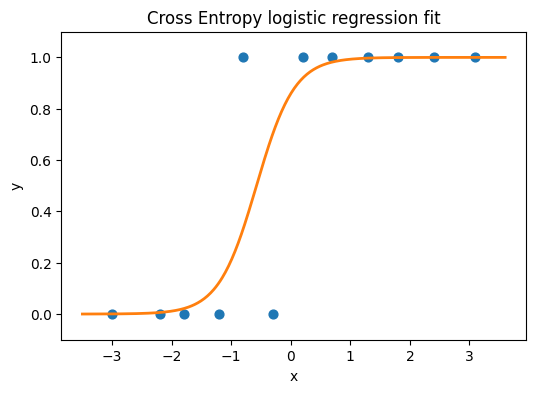

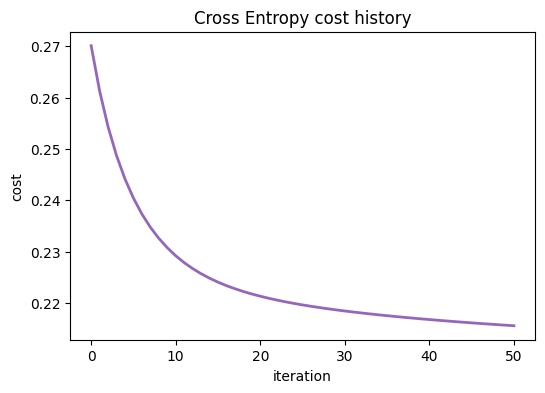

Final misclassifications = 2


In [3]:
# QUESTION HANDLED: Earlier 1D cross-entropy logistic regression exercise.
# ---------------------------------------------------------------------
# Fit the same style of 1D classifier using the binary cross-entropy loss.
# ---------------------------------------------------------------------
# Textbook equations used here: the log-error / cross-entropy setup in Equations
# (6.10)-(6.12), with Equation (6.12) giving the two-class cost minimized below.

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# HELPER IMPORTS AND FUNCTIONS: Common imports, optimization helpers, and synthetic
# dataset builders used across the Chapter 6 exercise cells below.
# ---------------------------------------------------------------------

def ensure_2d_features(X):
    # Most of the later helpers assume features are arranged as a matrix
    # of shape (P, N).  If X is a 1D array, treat it as a single-feature
    # dataset and promote it to shape (P, 1).
    X = np.asarray(X)
    return X[:, None] if X.ndim == 1 else X

def linear_model(X, w):
    # Generic linear score a(x) = w0 + w_1:N^T x that works for both the
    # 1D and multi-dimensional exercises in this notebook.
    X2 = ensure_2d_features(X)
    return w[0] + X2 @ w[1:]

def sigmoid(z):
    # Stable logistic sigmoid used throughout the notebook.
    z = np.clip(z, -100, 100)
    return 1.0 / (1.0 + np.exp(-z))

def gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=50, misclass_fn=None):
    # Standard fixed-step gradient descent.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    if misclass_fn is not None:
        misclass_history = [misclass_fn(w, X, y)]

    for _ in range(max_its):
        w = w - alpha * grad_fn(w, X, y)
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

        if misclass_fn is not None:
            misclass_history.append(misclass_fn(w, X, y))

    if misclass_fn is None:
        return np.array(weight_history), np.array(cost_history)

    return np.array(weight_history), np.array(cost_history), np.array(misclass_history)

def normalized_gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=100):
    # Variant that normalizes the gradient direction before each step.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(max_its):
        g = grad_fn(w, X, y)
        gnorm = np.linalg.norm(g)
        if gnorm < 1e-12:
            break
        w = w - alpha * g / gnorm
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)

def misclassifications_binary01(w, X, y):
    # Hard 0/1 predictions from sigmoid probabilities.
    preds = (sigmoid(linear_model(X, w)) >= 0.5).astype(int)
    return int(np.sum(preds != y))

def misclassifications_signed(w, X, y):
    # Hard {-1, +1} predictions from the sign of the linear score.
    preds = np.where(linear_model(X, w) >= 0, 1, -1)
    return int(np.sum(preds != y))

def softmax_cost_signed(w, X, y):
    # Two-class softmax/logistic loss for labels in {-1, +1}.
    margins = y * linear_model(X, w)
    return np.mean(np.logaddexp(0.0, -margins))

def grad_softmax_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = -y * sigmoid(-margins)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def perceptron_cost_signed(w, X, y):
    margins = y * linear_model(X, w)
    return np.mean(np.maximum(0.0, -margins))

def subgradient_perceptron_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = np.where(margins <= 0, -y, 0.0)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def first_perfect_step(misclass_history):
    perfect_steps = np.where(misclass_history == 0)[0]
    return None if perfect_steps.size == 0 else int(perfect_steps[0])

def make_noisy_2d_dataset(seed=8, flips=5):
    # Figure 6.10-style noisy 2D dataset used by Exercises 6.8,
    # 6.9, and 6.12.
    rng = np.random.RandomState(seed)
    class_neg = rng.multivariate_normal(
        mean=[-1.7, -1.2],
        cov=[[0.45, 0.10], [0.10, 0.45]],
        size=50,
    )
    class_pos = rng.multivariate_normal(
        mean=[1.7, 1.2],
        cov=[[0.45, -0.05], [-0.05, 0.45]],
        size=50,
    )
    X = np.vstack([class_neg, class_pos])
    y = np.concatenate([-np.ones(50), np.ones(50)])
    flip_indices = np.array([6, 18, 31, 64, 87][:flips]) if flips <= 5 else rng.choice(X.shape[0], size=flips, replace=False)
    y[flip_indices] *= -1
    return X, y, np.array(flip_indices)

def make_synthetic_breast_cancer_data(seed=11, noise=0.05, flips=10):
    # Synthetic 699-by-9 breast-cancer-style dataset for Exercise 6.13.
    rng = np.random.RandomState(seed)
    P = 699
    N = 9
    X = rng.randn(P, N)
    X[:, 1] = 0.6 * X[:, 0] + 0.8 * rng.randn(P)
    X[:, 3] = 0.5 * X[:, 2] + 0.8 * rng.randn(P)
    X[:, 5] = 0.4 * X[:, 4] + 0.8 * rng.randn(P)
    true_w = 2.5 * np.array([1.8, -1.5, 1.2, -1.0, 0.8, -0.7, 0.5, -0.4, 0.3])
    scores = X @ true_w + noise * rng.randn(P)
    y = np.where(scores >= 0, 1.0, -1.0)
    flip_indices = rng.choice(P, size=flips, replace=False)
    y[flip_indices] *= -1
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return X, y, flip_indices

def cross_entropy_binary(w, x, y):
    a = sigmoid(linear_model(x, w))
    a = np.clip(a, 1e-12, 1 - 1e-12)
    return -np.mean(y * np.log(a) + (1 - y) * np.log(1 - a))

def grad_cross_entropy_binary(w, x, y):
    a = sigmoid(linear_model(x, w))
    diff = a - y
    grad_w0 = np.mean(diff)
    grad_w1 = np.mean(diff * x)
    return np.array([grad_w0, grad_w1])

x_ce = np.array([-3.0, -2.2, -1.8, -1.2, -0.8, -0.3, 0.2, 0.7, 1.3, 1.8, 2.4, 3.1])
y_ce = np.array([0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1])
w_init_ce = np.array([3.0, 3.0])

weights_ce, costs_ce = gradient_descent(
    cross_entropy_binary,
    grad_cross_entropy_binary,
    w_init_ce,
    x_ce,
    y_ce,
    alpha=1.0,
    max_its=50,
)

w_final_ce = weights_ce[-1]
print('Final weights:', w_final_ce)
print('Final cost:', costs_ce[-1])
print('Misclassifications:', misclassifications_binary01(w_final_ce, x_ce, y_ce))

xx_ce = np.linspace(np.min(x_ce) - 0.5, np.max(x_ce) + 0.5, 400)
yy_ce = sigmoid(linear_model(xx_ce, w_final_ce))

plt.figure(figsize=(6, 4))
plt.scatter(x_ce, y_ce, s=40)
plt.plot(xx_ce, yy_ce, linewidth=2, color='tab:orange')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim([-0.1, 1.1])
plt.title('Cross Entropy logistic regression fit')
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(costs_ce, linewidth=2, color='tab:purple')
plt.xlabel('iteration')
plt.ylabel('cost')
plt.title('Cross Entropy cost history')
plt.show()

print('Final misclassifications =', misclassifications_binary01(w_final_ce, x_ce, y_ce))


Final weights: [1.7829506  4.28538441]
Final cost: 0.01040788696705132
Decision boundary x = -0.41605382921215833
Misclassifications: 0


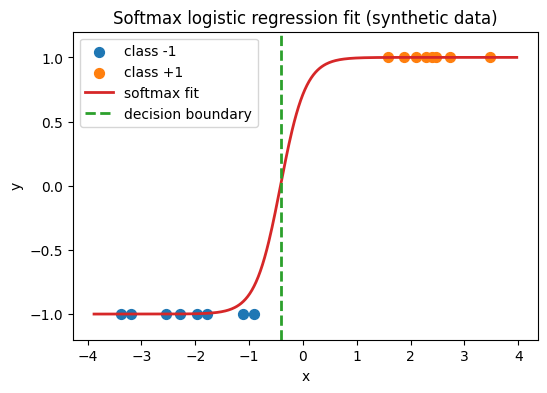

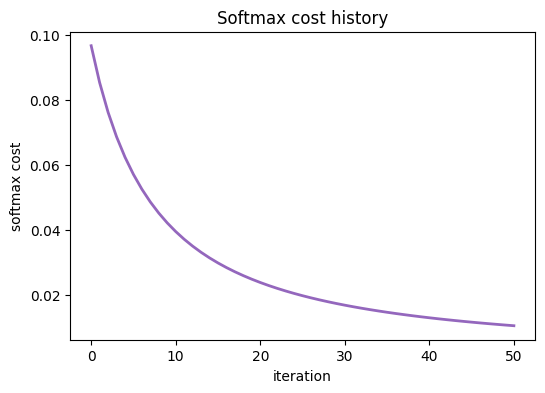

In [4]:
# QUESTION HANDLED: Exercise 6.7 - Implementing the Softmax cost.
# ---------------------------------------------------------------------
# Use the self-contained signed-label softmax helpers defined below on a linearly separable 1D
# synthetic dataset.
# ---------------------------------------------------------------------
# Textbook equations used here: the log-error Softmax form in Equation (6.21)
# and the full two-class Softmax cost in Equation (6.25).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# HELPER IMPORTS AND FUNCTIONS: Common imports, optimization helpers, and synthetic
# dataset builders used across the Chapter 6 exercise cells below.
# ---------------------------------------------------------------------

def ensure_2d_features(X):
    # Most of the later helpers assume features are arranged as a matrix
    # of shape (P, N).  If X is a 1D array, treat it as a single-feature
    # dataset and promote it to shape (P, 1).
    X = np.asarray(X)
    return X[:, None] if X.ndim == 1 else X

def linear_model(X, w):
    # Generic linear score a(x) = w0 + w_1:N^T x that works for both the
    # 1D and multi-dimensional exercises in this notebook.
    X2 = ensure_2d_features(X)
    return w[0] + X2 @ w[1:]

def sigmoid(z):
    # Stable logistic sigmoid used throughout the notebook.
    z = np.clip(z, -100, 100)
    return 1.0 / (1.0 + np.exp(-z))

def gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=50, misclass_fn=None):
    # Standard fixed-step gradient descent.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    if misclass_fn is not None:
        misclass_history = [misclass_fn(w, X, y)]

    for _ in range(max_its):
        w = w - alpha * grad_fn(w, X, y)
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

        if misclass_fn is not None:
            misclass_history.append(misclass_fn(w, X, y))

    if misclass_fn is None:
        return np.array(weight_history), np.array(cost_history)

    return np.array(weight_history), np.array(cost_history), np.array(misclass_history)

def normalized_gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=100):
    # Variant that normalizes the gradient direction before each step.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(max_its):
        g = grad_fn(w, X, y)
        gnorm = np.linalg.norm(g)
        if gnorm < 1e-12:
            break
        w = w - alpha * g / gnorm
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)

def misclassifications_binary01(w, X, y):
    # Hard 0/1 predictions from sigmoid probabilities.
    preds = (sigmoid(linear_model(X, w)) >= 0.5).astype(int)
    return int(np.sum(preds != y))

def misclassifications_signed(w, X, y):
    # Hard {-1, +1} predictions from the sign of the linear score.
    preds = np.where(linear_model(X, w) >= 0, 1, -1)
    return int(np.sum(preds != y))

def softmax_cost_signed(w, X, y):
    # Two-class softmax/logistic loss for labels in {-1, +1}.
    margins = y * linear_model(X, w)
    return np.mean(np.logaddexp(0.0, -margins))

def grad_softmax_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = -y * sigmoid(-margins)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def perceptron_cost_signed(w, X, y):
    margins = y * linear_model(X, w)
    return np.mean(np.maximum(0.0, -margins))

def subgradient_perceptron_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = np.where(margins <= 0, -y, 0.0)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def first_perfect_step(misclass_history):
    perfect_steps = np.where(misclass_history == 0)[0]
    return None if perfect_steps.size == 0 else int(perfect_steps[0])

def make_noisy_2d_dataset(seed=8, flips=5):
    # Figure 6.10-style noisy 2D dataset used by Exercises 6.8,
    # 6.9, and 6.12.
    rng = np.random.RandomState(seed)
    class_neg = rng.multivariate_normal(
        mean=[-1.7, -1.2],
        cov=[[0.45, 0.10], [0.10, 0.45]],
        size=50,
    )
    class_pos = rng.multivariate_normal(
        mean=[1.7, 1.2],
        cov=[[0.45, -0.05], [-0.05, 0.45]],
        size=50,
    )
    X = np.vstack([class_neg, class_pos])
    y = np.concatenate([-np.ones(50), np.ones(50)])
    flip_indices = np.array([6, 18, 31, 64, 87][:flips]) if flips <= 5 else rng.choice(X.shape[0], size=flips, replace=False)
    y[flip_indices] *= -1
    return X, y, np.array(flip_indices)

def make_synthetic_breast_cancer_data(seed=11, noise=0.05, flips=10):
    # Synthetic 699-by-9 breast-cancer-style dataset for Exercise 6.13.
    rng = np.random.RandomState(seed)
    P = 699
    N = 9
    X = rng.randn(P, N)
    X[:, 1] = 0.6 * X[:, 0] + 0.8 * rng.randn(P)
    X[:, 3] = 0.5 * X[:, 2] + 0.8 * rng.randn(P)
    X[:, 5] = 0.4 * X[:, 4] + 0.8 * rng.randn(P)
    true_w = 2.5 * np.array([1.8, -1.5, 1.2, -1.0, 0.8, -0.7, 0.5, -0.4, 0.3])
    scores = X @ true_w + noise * rng.randn(P)
    y = np.where(scores >= 0, 1.0, -1.0)
    flip_indices = rng.choice(P, size=flips, replace=False)
    y[flip_indices] *= -1
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return X, y, flip_indices

rng_softmax_1d = np.random.RandomState(6)
x_neg_67 = np.sort(rng_softmax_1d.uniform(-3.5, -0.6, 8))
x_pos_67 = np.sort(rng_softmax_1d.uniform(0.6, 3.5, 8))
x_67 = np.concatenate([x_neg_67, x_pos_67])
y_67 = np.concatenate([-np.ones_like(x_neg_67), np.ones_like(x_pos_67)])
w_init_67 = np.array([3.0, 3.0])

weights_67, costs_67 = gradient_descent(
    softmax_cost_signed,
    grad_softmax_signed,
    w_init_67,
    x_67,
    y_67,
    alpha=1.0,
    max_its=50,
)

w_final_67 = weights_67[-1]
decision_boundary_67 = -w_final_67[0] / w_final_67[1]
print('Final weights:', w_final_67)
print('Final cost:', costs_67[-1])
print('Decision boundary x =', decision_boundary_67)
print('Misclassifications:', misclassifications_signed(w_final_67, x_67, y_67))

xx_67 = np.linspace(np.min(x_67) - 0.5, np.max(x_67) + 0.5, 400)
yy_67 = 2.0 * sigmoid(linear_model(xx_67, w_final_67)) - 1.0

plt.figure(figsize=(6, 4))
plt.scatter(x_67[y_67 == -1], y_67[y_67 == -1], s=50, color='tab:blue', label='class -1')
plt.scatter(x_67[y_67 == 1], y_67[y_67 == 1], s=50, color='tab:orange', label='class +1')
plt.plot(xx_67, yy_67, color='tab:red', linewidth=2, label='softmax fit')
plt.axvline(decision_boundary_67, color='tab:green', linestyle='--', linewidth=2, label='decision boundary')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim([-1.2, 1.2])
plt.title('Softmax logistic regression fit (synthetic data)')
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(costs_67, linewidth=2, color='tab:purple')
plt.xlabel('iteration')
plt.ylabel('softmax cost')
plt.title('Softmax cost history')
plt.show()


Final weights: [0.04274956 1.37940843 0.40936597]
Final cost: 0.23646052908681303
Final misclassifications: 5
Minimum misclassifications during run: 5


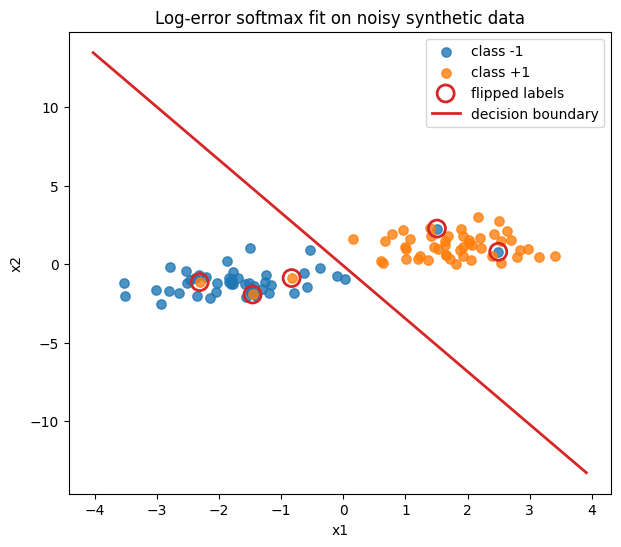

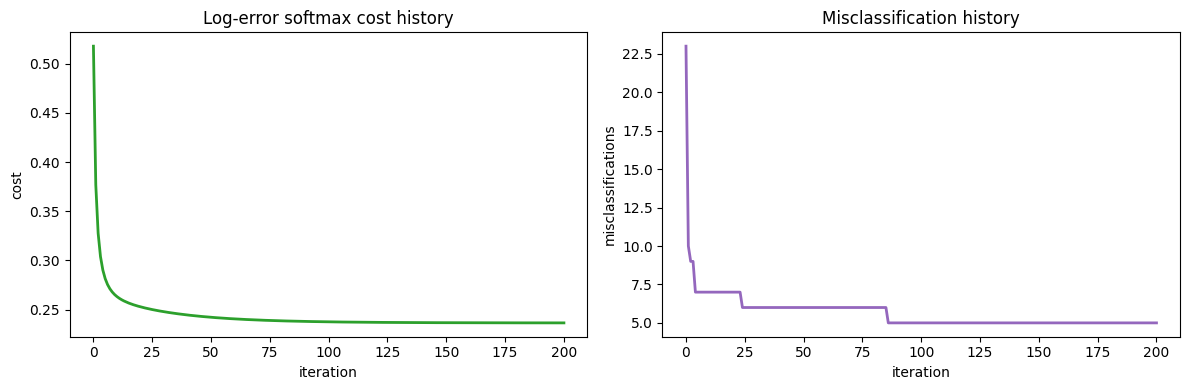

In [5]:
# QUESTION HANDLED: Exercise 6.8 - Implementing the Log Error version of Softmax.
# ---------------------------------------------------------------------
# For the two-class setting, the log-error form matches the self-contained signed
# softmax formulation.  Here we apply it to the noisy 2D dataset.
# ---------------------------------------------------------------------
# Textbook equations used here: the log-error based Softmax cost in Equation (6.21),
# whose pointwise form is equivalent to the Softmax expression in Equation (6.24).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# HELPER IMPORTS AND FUNCTIONS: Common imports, optimization helpers, and synthetic
# dataset builders used across the Chapter 6 exercise cells below.
# ---------------------------------------------------------------------

def ensure_2d_features(X):
    # Most of the later helpers assume features are arranged as a matrix
    # of shape (P, N).  If X is a 1D array, treat it as a single-feature
    # dataset and promote it to shape (P, 1).
    X = np.asarray(X)
    return X[:, None] if X.ndim == 1 else X

def linear_model(X, w):
    # Generic linear score a(x) = w0 + w_1:N^T x that works for both the
    # 1D and multi-dimensional exercises in this notebook.
    X2 = ensure_2d_features(X)
    return w[0] + X2 @ w[1:]

def sigmoid(z):
    # Stable logistic sigmoid used throughout the notebook.
    z = np.clip(z, -100, 100)
    return 1.0 / (1.0 + np.exp(-z))

def gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=50, misclass_fn=None):
    # Standard fixed-step gradient descent.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    if misclass_fn is not None:
        misclass_history = [misclass_fn(w, X, y)]

    for _ in range(max_its):
        w = w - alpha * grad_fn(w, X, y)
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

        if misclass_fn is not None:
            misclass_history.append(misclass_fn(w, X, y))

    if misclass_fn is None:
        return np.array(weight_history), np.array(cost_history)

    return np.array(weight_history), np.array(cost_history), np.array(misclass_history)

def normalized_gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=100):
    # Variant that normalizes the gradient direction before each step.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(max_its):
        g = grad_fn(w, X, y)
        gnorm = np.linalg.norm(g)
        if gnorm < 1e-12:
            break
        w = w - alpha * g / gnorm
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)

def misclassifications_binary01(w, X, y):
    # Hard 0/1 predictions from sigmoid probabilities.
    preds = (sigmoid(linear_model(X, w)) >= 0.5).astype(int)
    return int(np.sum(preds != y))

def misclassifications_signed(w, X, y):
    # Hard {-1, +1} predictions from the sign of the linear score.
    preds = np.where(linear_model(X, w) >= 0, 1, -1)
    return int(np.sum(preds != y))

def softmax_cost_signed(w, X, y):
    # Two-class softmax/logistic loss for labels in {-1, +1}.
    margins = y * linear_model(X, w)
    return np.mean(np.logaddexp(0.0, -margins))

def grad_softmax_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = -y * sigmoid(-margins)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def perceptron_cost_signed(w, X, y):
    margins = y * linear_model(X, w)
    return np.mean(np.maximum(0.0, -margins))

def subgradient_perceptron_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = np.where(margins <= 0, -y, 0.0)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def first_perfect_step(misclass_history):
    perfect_steps = np.where(misclass_history == 0)[0]
    return None if perfect_steps.size == 0 else int(perfect_steps[0])

def make_noisy_2d_dataset(seed=8, flips=5):
    # Figure 6.10-style noisy 2D dataset used by Exercises 6.8,
    # 6.9, and 6.12.
    rng = np.random.RandomState(seed)
    class_neg = rng.multivariate_normal(
        mean=[-1.7, -1.2],
        cov=[[0.45, 0.10], [0.10, 0.45]],
        size=50,
    )
    class_pos = rng.multivariate_normal(
        mean=[1.7, 1.2],
        cov=[[0.45, -0.05], [-0.05, 0.45]],
        size=50,
    )
    X = np.vstack([class_neg, class_pos])
    y = np.concatenate([-np.ones(50), np.ones(50)])
    flip_indices = np.array([6, 18, 31, 64, 87][:flips]) if flips <= 5 else rng.choice(X.shape[0], size=flips, replace=False)
    y[flip_indices] *= -1
    return X, y, np.array(flip_indices)

def make_synthetic_breast_cancer_data(seed=11, noise=0.05, flips=10):
    # Synthetic 699-by-9 breast-cancer-style dataset for Exercise 6.13.
    rng = np.random.RandomState(seed)
    P = 699
    N = 9
    X = rng.randn(P, N)
    X[:, 1] = 0.6 * X[:, 0] + 0.8 * rng.randn(P)
    X[:, 3] = 0.5 * X[:, 2] + 0.8 * rng.randn(P)
    X[:, 5] = 0.4 * X[:, 4] + 0.8 * rng.randn(P)
    true_w = 2.5 * np.array([1.8, -1.5, 1.2, -1.0, 0.8, -0.7, 0.5, -0.4, 0.3])
    scores = X @ true_w + noise * rng.randn(P)
    y = np.where(scores >= 0, 1.0, -1.0)
    flip_indices = rng.choice(P, size=flips, replace=False)
    y[flip_indices] *= -1
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return X, y, flip_indices

X_68, y_68, flip_indices_68 = make_noisy_2d_dataset(seed=8, flips=5)
w_init_68 = np.array([0.5, -0.25, 1.0])

weights_68, costs_68, mis_68 = gradient_descent(
    softmax_cost_signed,
    grad_softmax_signed,
    w_init_68,
    X_68,
    y_68,
    alpha=0.5,
    max_its=200,
    misclass_fn=misclassifications_signed,
)

w_final_68 = weights_68[-1]
final_mis_68 = misclassifications_signed(w_final_68, X_68, y_68)
print('Final weights:', w_final_68)
print('Final cost:', costs_68[-1])
print('Final misclassifications:', final_mis_68)
print('Minimum misclassifications during run:', mis_68.min())

plt.figure(figsize=(7, 6))
plt.scatter(X_68[y_68 == -1, 0], X_68[y_68 == -1, 1], s=45, color='tab:blue', alpha=0.8, label='class -1')
plt.scatter(X_68[y_68 == 1, 0], X_68[y_68 == 1, 1], s=45, color='tab:orange', alpha=0.8, label='class +1')
plt.scatter(
    X_68[flip_indices_68, 0],
    X_68[flip_indices_68, 1],
    s=150,
    facecolors='none',
    edgecolors='tab:red',
    linewidths=2,
    label='flipped labels',
)
x1_vals_68 = np.linspace(X_68[:, 0].min() - 0.5, X_68[:, 0].max() + 0.5, 300)
if abs(w_final_68[2]) > 1e-12:
    x2_vals_68 = -(w_final_68[0] + w_final_68[1] * x1_vals_68) / w_final_68[2]
    plt.plot(x1_vals_68, x2_vals_68, color='tab:red', linewidth=2, label='decision boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Log-error softmax fit on noisy synthetic data')
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(costs_68, linewidth=2, color='tab:green')
axes[0].set_xlabel('iteration')
axes[0].set_ylabel('cost')
axes[0].set_title('Log-error softmax cost history')
axes[1].plot(mis_68, linewidth=2, color='tab:purple')
axes[1].set_xlabel('iteration')
axes[1].set_ylabel('misclassifications')
axes[1].set_title('Misclassification history')
plt.tight_layout()
plt.show()


Shared random initialization: [ 0.49671415 -0.1382643   0.64768854]
alpha = 1e-1 -> final cost: 0.03236260818134088 , final misclassifications: 10
alpha = 1e-2 -> final cost: 0.07959893905308808 , final misclassifications: 16
alpha = 1e-1 -> minimum misclassifications: 10 at step 21
alpha = 1e-2 -> minimum misclassifications: 16 at step 46
Neither run achieves perfect classification on this noisy synthetic dataset.
alpha = 1e-1 reaches the lower minimum misclassification count first.


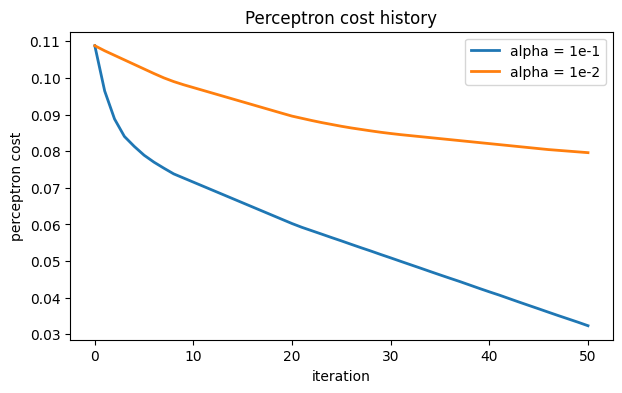

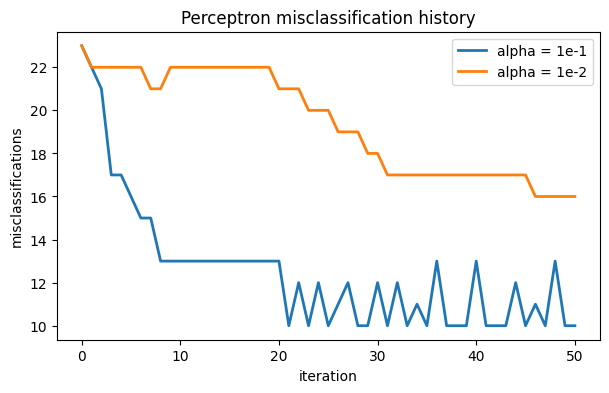

In [6]:
# QUESTION HANDLED: Exercise 6.9 - Using gradient descent to minimize the Perceptron cost.
# ---------------------------------------------------------------------
# Compare two fixed step sizes for perceptron-cost minimization on the
# noisy 2D dataset.
# ---------------------------------------------------------------------
# Textbook equations used here: the two-class Perceptron cost in Equation (6.33)
# and the standard gradient descent scheme discussed in Section 3.5.

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# HELPER IMPORTS AND FUNCTIONS: Common imports, optimization helpers, and synthetic
# dataset builders used across the Chapter 6 exercise cells below.
# ---------------------------------------------------------------------

def ensure_2d_features(X):
    # Most of the later helpers assume features are arranged as a matrix
    # of shape (P, N).  If X is a 1D array, treat it as a single-feature
    # dataset and promote it to shape (P, 1).
    X = np.asarray(X)
    return X[:, None] if X.ndim == 1 else X

def linear_model(X, w):
    # Generic linear score a(x) = w0 + w_1:N^T x that works for both the
    # 1D and multi-dimensional exercises in this notebook.
    X2 = ensure_2d_features(X)
    return w[0] + X2 @ w[1:]

def sigmoid(z):
    # Stable logistic sigmoid used throughout the notebook.
    z = np.clip(z, -100, 100)
    return 1.0 / (1.0 + np.exp(-z))

def gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=50, misclass_fn=None):
    # Standard fixed-step gradient descent.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    if misclass_fn is not None:
        misclass_history = [misclass_fn(w, X, y)]

    for _ in range(max_its):
        w = w - alpha * grad_fn(w, X, y)
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

        if misclass_fn is not None:
            misclass_history.append(misclass_fn(w, X, y))

    if misclass_fn is None:
        return np.array(weight_history), np.array(cost_history)

    return np.array(weight_history), np.array(cost_history), np.array(misclass_history)

def normalized_gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=100):
    # Variant that normalizes the gradient direction before each step.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(max_its):
        g = grad_fn(w, X, y)
        gnorm = np.linalg.norm(g)
        if gnorm < 1e-12:
            break
        w = w - alpha * g / gnorm
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)

def misclassifications_binary01(w, X, y):
    # Hard 0/1 predictions from sigmoid probabilities.
    preds = (sigmoid(linear_model(X, w)) >= 0.5).astype(int)
    return int(np.sum(preds != y))

def misclassifications_signed(w, X, y):
    # Hard {-1, +1} predictions from the sign of the linear score.
    preds = np.where(linear_model(X, w) >= 0, 1, -1)
    return int(np.sum(preds != y))

def softmax_cost_signed(w, X, y):
    # Two-class softmax/logistic loss for labels in {-1, +1}.
    margins = y * linear_model(X, w)
    return np.mean(np.logaddexp(0.0, -margins))

def grad_softmax_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = -y * sigmoid(-margins)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def perceptron_cost_signed(w, X, y):
    margins = y * linear_model(X, w)
    return np.mean(np.maximum(0.0, -margins))

def subgradient_perceptron_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = np.where(margins <= 0, -y, 0.0)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def first_perfect_step(misclass_history):
    perfect_steps = np.where(misclass_history == 0)[0]
    return None if perfect_steps.size == 0 else int(perfect_steps[0])

def make_noisy_2d_dataset(seed=8, flips=5):
    # Figure 6.10-style noisy 2D dataset used by Exercises 6.8,
    # 6.9, and 6.12.
    rng = np.random.RandomState(seed)
    class_neg = rng.multivariate_normal(
        mean=[-1.7, -1.2],
        cov=[[0.45, 0.10], [0.10, 0.45]],
        size=50,
    )
    class_pos = rng.multivariate_normal(
        mean=[1.7, 1.2],
        cov=[[0.45, -0.05], [-0.05, 0.45]],
        size=50,
    )
    X = np.vstack([class_neg, class_pos])
    y = np.concatenate([-np.ones(50), np.ones(50)])
    flip_indices = np.array([6, 18, 31, 64, 87][:flips]) if flips <= 5 else rng.choice(X.shape[0], size=flips, replace=False)
    y[flip_indices] *= -1
    return X, y, np.array(flip_indices)

def make_synthetic_breast_cancer_data(seed=11, noise=0.05, flips=10):
    # Synthetic 699-by-9 breast-cancer-style dataset for Exercise 6.13.
    rng = np.random.RandomState(seed)
    P = 699
    N = 9
    X = rng.randn(P, N)
    X[:, 1] = 0.6 * X[:, 0] + 0.8 * rng.randn(P)
    X[:, 3] = 0.5 * X[:, 2] + 0.8 * rng.randn(P)
    X[:, 5] = 0.4 * X[:, 4] + 0.8 * rng.randn(P)
    true_w = 2.5 * np.array([1.8, -1.5, 1.2, -1.0, 0.8, -0.7, 0.5, -0.4, 0.3])
    scores = X @ true_w + noise * rng.randn(P)
    y = np.where(scores >= 0, 1.0, -1.0)
    flip_indices = rng.choice(P, size=flips, replace=False)
    y[flip_indices] *= -1
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return X, y, flip_indices

X_69, y_69, flip_indices_69 = make_noisy_2d_dataset(seed=8, flips=5)
w_init_69 = np.random.RandomState(42).randn(3)

weights_fast_69, costs_fast_69, mis_fast_69 = gradient_descent(
    perceptron_cost_signed,
    subgradient_perceptron_signed,
    w_init_69,
    X_69,
    y_69,
    alpha=1e-1,
    max_its=50,
    misclass_fn=misclassifications_signed,
)
weights_slow_69, costs_slow_69, mis_slow_69 = gradient_descent(
    perceptron_cost_signed,
    subgradient_perceptron_signed,
    w_init_69,
    X_69,
    y_69,
    alpha=1e-2,
    max_its=50,
    misclass_fn=misclassifications_signed,
)

first_fast_69 = first_perfect_step(mis_fast_69)
first_slow_69 = first_perfect_step(mis_slow_69)

print('Shared random initialization:', w_init_69)
print('alpha = 1e-1 -> final cost:', costs_fast_69[-1], ', final misclassifications:', mis_fast_69[-1])
print('alpha = 1e-2 -> final cost:', costs_slow_69[-1], ', final misclassifications:', mis_slow_69[-1])
print('alpha = 1e-1 -> minimum misclassifications:', mis_fast_69.min(), 'at step', mis_fast_69.argmin())
print('alpha = 1e-2 -> minimum misclassifications:', mis_slow_69.min(), 'at step', mis_slow_69.argmin())
if first_fast_69 is not None or first_slow_69 is not None:
    print('First perfect step for alpha = 1e-1:', first_fast_69)
    print('First perfect step for alpha = 1e-2:', first_slow_69)
else:
    print('Neither run achieves perfect classification on this noisy synthetic dataset.')
    if mis_fast_69.min() < mis_slow_69.min():
        print('alpha = 1e-1 reaches the lower minimum misclassification count first.')
    elif mis_slow_69.min() < mis_fast_69.min():
        print('alpha = 1e-2 reaches the lower minimum misclassification count first.')
    elif mis_fast_69.argmin() < mis_slow_69.argmin():
        print('Both runs reach the same best misclassification count, but alpha = 1e-1 gets there first.')
    elif mis_slow_69.argmin() < mis_fast_69.argmin():
        print('Both runs reach the same best misclassification count, but alpha = 1e-2 gets there first.')
    else:
        print('Both runs reach the same best misclassification count at the same step.')

plt.figure(figsize=(7, 4))
plt.plot(costs_fast_69, linewidth=2, label='alpha = 1e-1')
plt.plot(costs_slow_69, linewidth=2, label='alpha = 1e-2')
plt.xlabel('iteration')
plt.ylabel('perceptron cost')
plt.title('Perceptron cost history')
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(mis_fast_69, linewidth=2, label='alpha = 1e-1')
plt.plot(mis_slow_69, linewidth=2, label='alpha = 1e-2')
plt.xlabel('iteration')
plt.ylabel('misclassifications')
plt.title('Perceptron misclassification history')
plt.legend()
plt.show()


Initial weights: [ 0.05056171  0.49995133 -0.99590893]
Final weights: [0.04244979 1.13835473 0.08747533]
Final cost: 0.27010811354177044
Final misclassifications: 5
Minimum misclassifications during run: 5


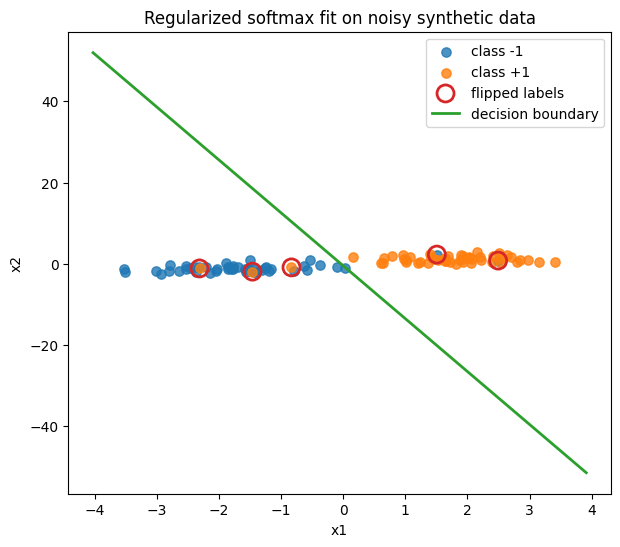

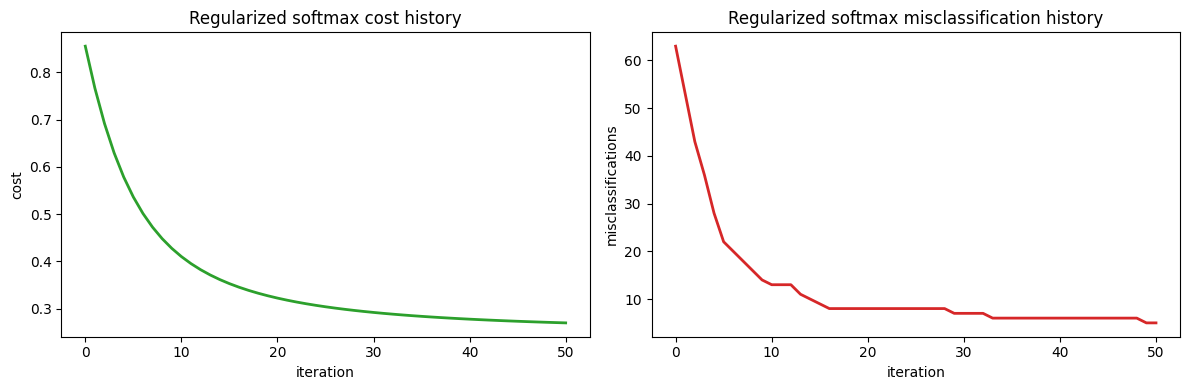

In [7]:
# QUESTION HANDLED: Exercise 6.12 - The regularized Softmax.
# ---------------------------------------------------------------------
# Use signed-distance normalization so the softmax loss depends on the
# distance to the boundary rather than on an arbitrary scaling of omega.
# ---------------------------------------------------------------------
# Textbook equations used here: the regularized Softmax cost in Equation (6.47),
# built from the two-class Softmax in Equation (6.25).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# HELPER IMPORTS AND FUNCTIONS: Common imports, optimization helpers, and synthetic
# dataset builders used across the Chapter 6 exercise cells below.
# ---------------------------------------------------------------------

def ensure_2d_features(X):
    # Most of the later helpers assume features are arranged as a matrix
    # of shape (P, N).  If X is a 1D array, treat it as a single-feature
    # dataset and promote it to shape (P, 1).
    X = np.asarray(X)
    return X[:, None] if X.ndim == 1 else X

def linear_model(X, w):
    # Generic linear score a(x) = w0 + w_1:N^T x that works for both the
    # 1D and multi-dimensional exercises in this notebook.
    X2 = ensure_2d_features(X)
    return w[0] + X2 @ w[1:]

def sigmoid(z):
    # Stable logistic sigmoid used throughout the notebook.
    z = np.clip(z, -100, 100)
    return 1.0 / (1.0 + np.exp(-z))

def gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=50, misclass_fn=None):
    # Standard fixed-step gradient descent.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    if misclass_fn is not None:
        misclass_history = [misclass_fn(w, X, y)]

    for _ in range(max_its):
        w = w - alpha * grad_fn(w, X, y)
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

        if misclass_fn is not None:
            misclass_history.append(misclass_fn(w, X, y))

    if misclass_fn is None:
        return np.array(weight_history), np.array(cost_history)

    return np.array(weight_history), np.array(cost_history), np.array(misclass_history)

def normalized_gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=100):
    # Variant that normalizes the gradient direction before each step.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(max_its):
        g = grad_fn(w, X, y)
        gnorm = np.linalg.norm(g)
        if gnorm < 1e-12:
            break
        w = w - alpha * g / gnorm
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)

def misclassifications_binary01(w, X, y):
    # Hard 0/1 predictions from sigmoid probabilities.
    preds = (sigmoid(linear_model(X, w)) >= 0.5).astype(int)
    return int(np.sum(preds != y))

def misclassifications_signed(w, X, y):
    # Hard {-1, +1} predictions from the sign of the linear score.
    preds = np.where(linear_model(X, w) >= 0, 1, -1)
    return int(np.sum(preds != y))

def softmax_cost_signed(w, X, y):
    # Two-class softmax/logistic loss for labels in {-1, +1}.
    margins = y * linear_model(X, w)
    return np.mean(np.logaddexp(0.0, -margins))

def grad_softmax_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = -y * sigmoid(-margins)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def perceptron_cost_signed(w, X, y):
    margins = y * linear_model(X, w)
    return np.mean(np.maximum(0.0, -margins))

def subgradient_perceptron_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = np.where(margins <= 0, -y, 0.0)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def first_perfect_step(misclass_history):
    perfect_steps = np.where(misclass_history == 0)[0]
    return None if perfect_steps.size == 0 else int(perfect_steps[0])

def make_noisy_2d_dataset(seed=8, flips=5):
    # Figure 6.10-style noisy 2D dataset used by Exercises 6.8,
    # 6.9, and 6.12.
    rng = np.random.RandomState(seed)
    class_neg = rng.multivariate_normal(
        mean=[-1.7, -1.2],
        cov=[[0.45, 0.10], [0.10, 0.45]],
        size=50,
    )
    class_pos = rng.multivariate_normal(
        mean=[1.7, 1.2],
        cov=[[0.45, -0.05], [-0.05, 0.45]],
        size=50,
    )
    X = np.vstack([class_neg, class_pos])
    y = np.concatenate([-np.ones(50), np.ones(50)])
    flip_indices = np.array([6, 18, 31, 64, 87][:flips]) if flips <= 5 else rng.choice(X.shape[0], size=flips, replace=False)
    y[flip_indices] *= -1
    return X, y, np.array(flip_indices)

def make_synthetic_breast_cancer_data(seed=11, noise=0.05, flips=10):
    # Synthetic 699-by-9 breast-cancer-style dataset for Exercise 6.13.
    rng = np.random.RandomState(seed)
    P = 699
    N = 9
    X = rng.randn(P, N)
    X[:, 1] = 0.6 * X[:, 0] + 0.8 * rng.randn(P)
    X[:, 3] = 0.5 * X[:, 2] + 0.8 * rng.randn(P)
    X[:, 5] = 0.4 * X[:, 4] + 0.8 * rng.randn(P)
    true_w = 2.5 * np.array([1.8, -1.5, 1.2, -1.0, 0.8, -0.7, 0.5, -0.4, 0.3])
    scores = X @ true_w + noise * rng.randn(P)
    y = np.where(scores >= 0, 1.0, -1.0)
    flip_indices = rng.choice(P, size=flips, replace=False)
    y[flip_indices] *= -1
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return X, y, flip_indices

def signed_distance_scores(w, X, eps=1e-12):
    X2 = ensure_2d_features(X)
    b = w[0]
    omega = w[1:]
    norm_omega = max(np.linalg.norm(omega), eps)
    raw_scores = b + X2 @ omega
    distances = raw_scores / norm_omega
    return distances, norm_omega, raw_scores, omega

def regularized_softmax_cost(w, X, y):
    distances, _, _, _ = signed_distance_scores(w, X)
    return np.mean(np.logaddexp(0.0, -y * distances))

def grad_regularized_softmax(w, X, y):
    X2 = ensure_2d_features(X)
    distances, norm_omega, raw_scores, omega = signed_distance_scores(w, X2)
    coeff = -y * sigmoid(-y * distances)
    grad_b = np.mean(coeff / norm_omega)
    omega_terms = X2 / norm_omega - np.outer(raw_scores, omega) / (norm_omega ** 3)
    grad_omega = np.mean(coeff[:, None] * omega_terms, axis=0)
    return np.concatenate([[grad_b], grad_omega])

def misclassifications_regularized(w, X, y):
    distances, _, _, _ = signed_distance_scores(w, X)
    preds = np.where(distances >= 0, 1, -1)
    return int(np.sum(preds != y))

X_612, y_612, flip_indices_612 = make_noisy_2d_dataset(seed=8, flips=5)
w_init_612 = np.array([0.05056171, 0.49995133, -0.99590893])

weights_612, costs_612, mis_612 = gradient_descent(
    regularized_softmax_cost,
    grad_regularized_softmax,
    w_init_612,
    X_612,
    y_612,
    alpha=0.1,
    max_its=50,
    misclass_fn=misclassifications_regularized,
)

w_final_612 = weights_612[-1]
final_mis_612 = misclassifications_regularized(w_final_612, X_612, y_612)
print('Initial weights:', w_init_612)
print('Final weights:', w_final_612)
print('Final cost:', costs_612[-1])
print('Final misclassifications:', final_mis_612)
print('Minimum misclassifications during run:', mis_612.min())

plt.figure(figsize=(7, 6))
plt.scatter(X_612[y_612 == -1, 0], X_612[y_612 == -1, 1], s=45, color='tab:blue', alpha=0.8, label='class -1')
plt.scatter(X_612[y_612 == 1, 0], X_612[y_612 == 1, 1], s=45, color='tab:orange', alpha=0.8, label='class +1')
plt.scatter(
    X_612[flip_indices_612, 0],
    X_612[flip_indices_612, 1],
    s=150,
    facecolors='none',
    edgecolors='tab:red',
    linewidths=2,
    label='flipped labels',
)
x1_vals_612 = np.linspace(X_612[:, 0].min() - 0.5, X_612[:, 0].max() + 0.5, 300)
if abs(w_final_612[2]) > 1e-12:
    x2_vals_612 = -(w_final_612[0] + w_final_612[1] * x1_vals_612) / w_final_612[2]
    plt.plot(x1_vals_612, x2_vals_612, color='tab:green', linewidth=2, label='decision boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Regularized softmax fit on noisy synthetic data')
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(costs_612, linewidth=2, color='tab:green')
axes[0].set_xlabel('iteration')
axes[0].set_ylabel('cost')
axes[0].set_title('Regularized softmax cost history')
axes[1].plot(mis_612, linewidth=2, color='tab:red')
axes[1].set_xlabel('iteration')
axes[1].set_ylabel('misclassifications')
axes[1].set_title('Regularized softmax misclassification history')
plt.tight_layout()
plt.show()


Dataset shape: (699, 9)
Shared initialization: [ 1.62434536 -0.61175641 -0.52817175 -1.07296862  0.86540763 -2.3015387
  1.74481176 -0.7612069   0.3190391  -0.24937038]
Softmax minimum misclassifications: 21 at step 296
Perceptron minimum misclassifications: 20 at step 296
Perceptron achieves the lower minimum misclassification count on this synthetic dataset.


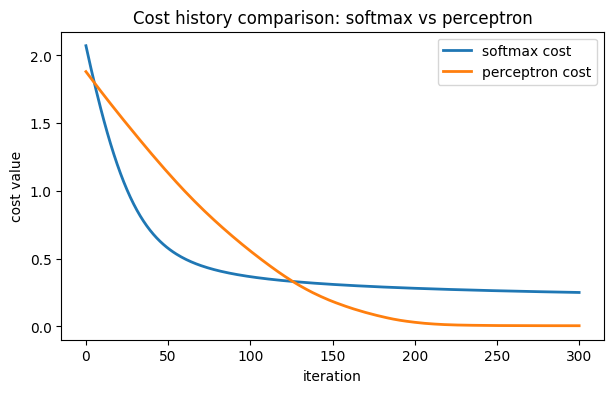

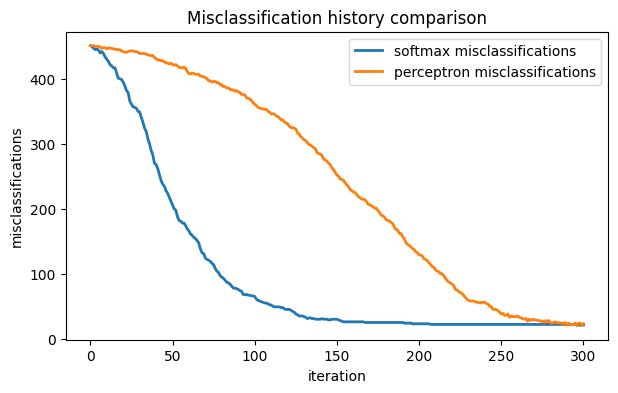

In [8]:
# QUESTION HANDLED: Exercise 6.13 - Compare the efficacy of two-class cost functions I.
# ---------------------------------------------------------------------
# Compare softmax and perceptron minimization on a synthetic 699-by-9
# breast-cancer-style dataset.
# ---------------------------------------------------------------------
# Textbook equations used here: the two-class Softmax cost in Equation (6.25)
# and the two-class Perceptron cost in Equation (6.33).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# HELPER IMPORTS AND FUNCTIONS: Common imports, optimization helpers, and synthetic
# dataset builders used across the Chapter 6 exercise cells below.
# ---------------------------------------------------------------------

def ensure_2d_features(X):
    # Most of the later helpers assume features are arranged as a matrix
    # of shape (P, N).  If X is a 1D array, treat it as a single-feature
    # dataset and promote it to shape (P, 1).
    X = np.asarray(X)
    return X[:, None] if X.ndim == 1 else X

def linear_model(X, w):
    # Generic linear score a(x) = w0 + w_1:N^T x that works for both the
    # 1D and multi-dimensional exercises in this notebook.
    X2 = ensure_2d_features(X)
    return w[0] + X2 @ w[1:]

def sigmoid(z):
    # Stable logistic sigmoid used throughout the notebook.
    z = np.clip(z, -100, 100)
    return 1.0 / (1.0 + np.exp(-z))

def gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=50, misclass_fn=None):
    # Standard fixed-step gradient descent.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    if misclass_fn is not None:
        misclass_history = [misclass_fn(w, X, y)]

    for _ in range(max_its):
        w = w - alpha * grad_fn(w, X, y)
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

        if misclass_fn is not None:
            misclass_history.append(misclass_fn(w, X, y))

    if misclass_fn is None:
        return np.array(weight_history), np.array(cost_history)

    return np.array(weight_history), np.array(cost_history), np.array(misclass_history)

def normalized_gradient_descent(cost_fn, grad_fn, w0, X, y, alpha=1.0, max_its=100):
    # Variant that normalizes the gradient direction before each step.
    w = w0.astype(float).copy()
    weight_history = [w.copy()]
    cost_history = [cost_fn(w, X, y)]

    for _ in range(max_its):
        g = grad_fn(w, X, y)
        gnorm = np.linalg.norm(g)
        if gnorm < 1e-12:
            break
        w = w - alpha * g / gnorm
        weight_history.append(w.copy())
        cost_history.append(cost_fn(w, X, y))

    return np.array(weight_history), np.array(cost_history)

def misclassifications_binary01(w, X, y):
    # Hard 0/1 predictions from sigmoid probabilities.
    preds = (sigmoid(linear_model(X, w)) >= 0.5).astype(int)
    return int(np.sum(preds != y))

def misclassifications_signed(w, X, y):
    # Hard {-1, +1} predictions from the sign of the linear score.
    preds = np.where(linear_model(X, w) >= 0, 1, -1)
    return int(np.sum(preds != y))

def softmax_cost_signed(w, X, y):
    # Two-class softmax/logistic loss for labels in {-1, +1}.
    margins = y * linear_model(X, w)
    return np.mean(np.logaddexp(0.0, -margins))

def grad_softmax_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = -y * sigmoid(-margins)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def perceptron_cost_signed(w, X, y):
    margins = y * linear_model(X, w)
    return np.mean(np.maximum(0.0, -margins))

def subgradient_perceptron_signed(w, X, y):
    X2 = ensure_2d_features(X)
    margins = y * linear_model(X2, w)
    coeff = np.where(margins <= 0, -y, 0.0)
    grad_w0 = np.mean(coeff)
    grad_rest = (X2.T @ coeff) / X2.shape[0]
    return np.concatenate([[grad_w0], grad_rest])

def first_perfect_step(misclass_history):
    perfect_steps = np.where(misclass_history == 0)[0]
    return None if perfect_steps.size == 0 else int(perfect_steps[0])

def make_noisy_2d_dataset(seed=8, flips=5):
    # Figure 6.10-style noisy 2D dataset used by Exercises 6.8,
    # 6.9, and 6.12.
    rng = np.random.RandomState(seed)
    class_neg = rng.multivariate_normal(
        mean=[-1.7, -1.2],
        cov=[[0.45, 0.10], [0.10, 0.45]],
        size=50,
    )
    class_pos = rng.multivariate_normal(
        mean=[1.7, 1.2],
        cov=[[0.45, -0.05], [-0.05, 0.45]],
        size=50,
    )
    X = np.vstack([class_neg, class_pos])
    y = np.concatenate([-np.ones(50), np.ones(50)])
    flip_indices = np.array([6, 18, 31, 64, 87][:flips]) if flips <= 5 else rng.choice(X.shape[0], size=flips, replace=False)
    y[flip_indices] *= -1
    return X, y, np.array(flip_indices)

def make_synthetic_breast_cancer_data(seed=11, noise=0.05, flips=10):
    # Synthetic 699-by-9 breast-cancer-style dataset for Exercise 6.13.
    rng = np.random.RandomState(seed)
    P = 699
    N = 9
    X = rng.randn(P, N)
    X[:, 1] = 0.6 * X[:, 0] + 0.8 * rng.randn(P)
    X[:, 3] = 0.5 * X[:, 2] + 0.8 * rng.randn(P)
    X[:, 5] = 0.4 * X[:, 4] + 0.8 * rng.randn(P)
    true_w = 2.5 * np.array([1.8, -1.5, 1.2, -1.0, 0.8, -0.7, 0.5, -0.4, 0.3])
    scores = X @ true_w + noise * rng.randn(P)
    y = np.where(scores >= 0, 1.0, -1.0)
    flip_indices = rng.choice(P, size=flips, replace=False)
    y[flip_indices] *= -1
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return X, y, flip_indices

X_613, y_613, flipped_labels_613 = make_synthetic_breast_cancer_data(seed=11, noise=0.05, flips=10)
w_init_613 = np.random.RandomState(1).randn(X_613.shape[1] + 1)

softmax_weights, softmax_cost_history, softmax_misclass_history = gradient_descent(
    softmax_cost_signed,
    grad_softmax_signed,
    w_init_613,
    X_613,
    y_613,
    alpha=0.2,
    max_its=300,
    misclass_fn=misclassifications_signed,
)
perceptron_weights, perceptron_cost_history, perceptron_misclass_history = gradient_descent(
    perceptron_cost_signed,
    subgradient_perceptron_signed,
    w_init_613,
    X_613,
    y_613,
    alpha=0.05,
    max_its=300,
    misclass_fn=misclassifications_signed,
)

softmax_best = int(softmax_misclass_history.min())
perceptron_best = int(perceptron_misclass_history.min())

# Expose the dataset under simple names so the visualization cell below
# can consume it directly.
X = X_613
y = y_613

print('Dataset shape:', X_613.shape)
print('Shared initialization:', w_init_613)
print('Softmax minimum misclassifications:', softmax_best, 'at step', int(softmax_misclass_history.argmin()))
print('Perceptron minimum misclassifications:', perceptron_best, 'at step', int(perceptron_misclass_history.argmin()))
if softmax_best < perceptron_best:
    print('Softmax achieves the lower minimum misclassification count on this synthetic dataset.')
elif perceptron_best < softmax_best:
    print('Perceptron achieves the lower minimum misclassification count on this synthetic dataset.')
else:
    print('Both methods reach the same minimum misclassification count on this synthetic dataset.')

plt.figure(figsize=(7, 4))
plt.plot(softmax_cost_history, linewidth=2, label='softmax cost')
plt.plot(perceptron_cost_history, linewidth=2, label='perceptron cost')
plt.xlabel('iteration')
plt.ylabel('cost value')
plt.title('Cost history comparison: softmax vs perceptron')
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(softmax_misclass_history, linewidth=2, label='softmax misclassifications')
plt.plot(perceptron_misclass_history, linewidth=2, label='perceptron misclassifications')
plt.xlabel('iteration')
plt.ylabel('misclassifications')
plt.title('Misclassification history comparison')
plt.legend()
plt.show()


Softmax minimum misclassifications: 12
Perceptron minimum misclassifications: 10


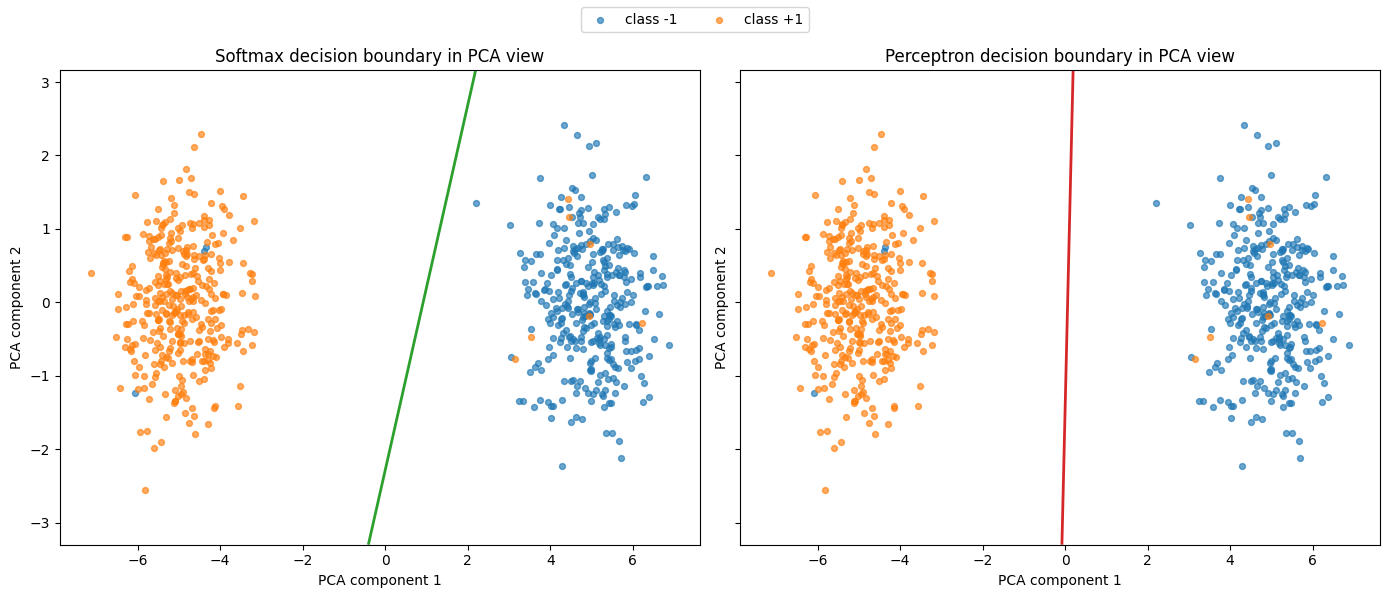

In [9]:
# QUESTION HANDLED: Exercise 6.13 - Raw data and evaluated decision-boundary plots.
# ---------------------------------------------------------------------
# Textbook equations used here: the two-class Softmax cost in Equation (6.25)
# and the two-class Perceptron cost in Equation (6.33).
# The 6.13 dataset is 9D, so this self-contained cell rebuilds the dataset,
# retrains both models, projects the raw data to a 2D PCA plane, and then
# evaluates the learned decision boundaries over that plane.
# ---------------------------------------------------------------------

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# HELPER IMPORTS AND FUNCTIONS: Common imports, optimization helpers, and synthetic
# dataset generators reused across the Chapter 6 exercise cells.
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'


def sigmoid(t):
    t = np.clip(t, -50, 50)
    return 1.0 / (1.0 + np.exp(-t))


def linear_model(x, w):
    x = np.asarray(x)
    if x.ndim == 1:
        return w[0] + np.dot(x, w[1:])
    return w[0] + x @ w[1:]


def gradient_descent(cost_fn, grad_fn, w_init, x, y, alpha, max_its, misclass_fn=None):
    w = np.asarray(w_init, dtype=float).copy()
    weight_history = [w.copy()]
    cost_history = [float(cost_fn(w, x, y))]
    misclass_history = []
    if misclass_fn is not None:
        misclass_history.append(int(misclass_fn(w, x, y)))

    for _ in range(max_its):
        grad = np.asarray(grad_fn(w, x, y), dtype=float)
        w = w - alpha * grad
        weight_history.append(w.copy())
        cost_history.append(float(cost_fn(w, x, y)))
        if misclass_fn is not None:
            misclass_history.append(int(misclass_fn(w, x, y)))

    return np.array(weight_history), np.array(cost_history), np.array(misclass_history)


def misclassifications_signed(w, x, y):
    predictions = np.sign(linear_model(x, w))
    predictions[predictions == 0] = 1
    return np.sum(predictions != y)


def softmax_cost_signed(w, x, y):
    margins = y * linear_model(x, w)
    return np.mean(np.log1p(np.exp(-margins)))


def grad_softmax_signed(w, x, y):
    scores = linear_model(x, w)
    margins = y * scores
    weights = -y / (1.0 + np.exp(np.clip(margins, -50, 50)))
    grad = np.empty_like(w)
    grad[0] = np.mean(weights)
    grad[1:] = np.mean(weights[:, None] * x, axis=0)
    return grad


def perceptron_cost_signed(w, x, y):
    margins = y * linear_model(x, w)
    return np.mean(np.maximum(0.0, -margins))


def subgradient_perceptron_signed(w, x, y):
    margins = y * linear_model(x, w)
    active = margins < 0
    grad = np.zeros_like(w)
    if np.any(active):
        active_weights = -y[active]
        grad[0] = np.mean(active_weights)
        grad[1:] = np.mean(active_weights[:, None] * x[active], axis=0)
    return grad


def make_synthetic_breast_cancer_data(seed=11, noise=0.05, flips=10):
    rng = np.random.default_rng(seed)
    num_points = 699
    num_features = 9

    positive_mean = np.array([2.0, 1.8, 1.9, 1.5, 1.6, 1.7, 1.4, 1.3, 1.5])
    negative_mean = -positive_mean
    covariance = 0.55 * np.eye(num_features)

    x_pos = rng.multivariate_normal(positive_mean, covariance, size=num_points // 2)
    x_neg = rng.multivariate_normal(negative_mean, covariance, size=num_points - num_points // 2)

    X = np.vstack([x_pos, x_neg])
    y = np.hstack([np.ones(x_pos.shape[0], dtype=int), -np.ones(x_neg.shape[0], dtype=int)])

    X = X + noise * rng.normal(size=X.shape)

    flipped_labels = np.array([], dtype=int)
    if flips > 0:
        flipped_labels = rng.choice(num_points, size=flips, replace=False)
        y[flipped_labels] *= -1

    shuffle = rng.permutation(num_points)
    return X[shuffle], y[shuffle], flipped_labels


# ---------------------------------------------------------------------
# Rebuild the Exercise 6.13 dataset and retrain both classifiers so this cell
# does not depend on variables created elsewhere in the notebook.
# ---------------------------------------------------------------------
X_613, y_613, _ = make_synthetic_breast_cancer_data(seed=11, noise=0.05, flips=10)
w_init_613 = np.random.RandomState(1).randn(X_613.shape[1] + 1)

softmax_weights, _, softmax_misclass_history = gradient_descent(
    softmax_cost_signed,
    grad_softmax_signed,
    w_init_613,
    X_613,
    y_613,
    alpha=0.2,
    max_its=300,
    misclass_fn=misclassifications_signed,
)
perceptron_weights, _, perceptron_misclass_history = gradient_descent(
    perceptron_cost_signed,
    subgradient_perceptron_signed,
    w_init_613,
    X_613,
    y_613,
    alpha=0.05,
    max_its=300,
    misclass_fn=misclassifications_signed,
)

# Compute a 2D PCA view of the 9D raw data so both the point cloud and the
# zero-score decision boundaries can be visualized in a single figure.
X_mean = X_613.mean(axis=0)
X_centered = X_613 - X_mean
_, _, Vt = np.linalg.svd(X_centered, full_matrices=False)
pca_basis = Vt[:2].T
X_pca = X_centered @ pca_basis


def project_grid_to_original(pc1_grid, pc2_grid, mean_vector, basis):
    flat_points = np.column_stack([pc1_grid.ravel(), pc2_grid.ravel()])
    return mean_vector + flat_points @ basis.T


pad = 0.75
pc1_vals = np.linspace(X_pca[:, 0].min() - pad, X_pca[:, 0].max() + pad, 300)
pc2_vals = np.linspace(X_pca[:, 1].min() - pad, X_pca[:, 1].max() + pad, 300)
PC1, PC2 = np.meshgrid(pc1_vals, pc2_vals)
X_grid_original = project_grid_to_original(PC1, PC2, X_mean, pca_basis)

softmax_scores_grid = linear_model(X_grid_original, softmax_weights[-1]).reshape(PC1.shape)
perceptron_scores_grid = linear_model(X_grid_original, perceptron_weights[-1]).reshape(PC1.shape)

print('Softmax minimum misclassifications:', int(softmax_misclass_history.min()))
print('Perceptron minimum misclassifications:', int(perceptron_misclass_history.min()))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax in axes:
    ax.scatter(X_pca[y_613 == -1, 0], X_pca[y_613 == -1, 1], s=18, color='tab:blue', alpha=0.65, label='class -1')
    ax.scatter(X_pca[y_613 == 1, 0], X_pca[y_613 == 1, 1], s=18, color='tab:orange', alpha=0.65, label='class +1')
    ax.set_xlabel('PCA component 1')
    ax.set_ylabel('PCA component 2')

axes[0].contour(PC1, PC2, softmax_scores_grid, levels=[0], colors=['tab:green'], linewidths=2)
axes[0].set_title('Softmax decision boundary in PCA view')
axes[1].contour(PC1, PC2, perceptron_scores_grid, levels=[0], colors=['tab:red'], linewidths=2)
axes[1].set_title('Perceptron decision boundary in PCA view')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
